## Sales Prediction

### 🎯 Goal:
Build a regression model to predict product sales based on advertising spend across different channels (TV, Radio, Newspaper).

### 🪜 Steps:
1. Load and explore dataset
2. Handle missing values
3. Perform data visualization (EDA)
4. Analyze feature relationships
5. Split data into training and testing sets
6. Train Linear Regression model
7. Evaluate model performance
8. Visualize predictions vs actual values

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

## Load Data

In [2]:
data4 = pd.read_csv(r"D:\Downloads\archive (4)\Advertising.csv")
data4.columns = data4.columns.str.strip() #Clean columns

## Handle Missing Values

In [3]:
data4 = data4.dropna()

## Explore

In [4]:
print(data4.head())
print(data4.describe())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000


## EDA

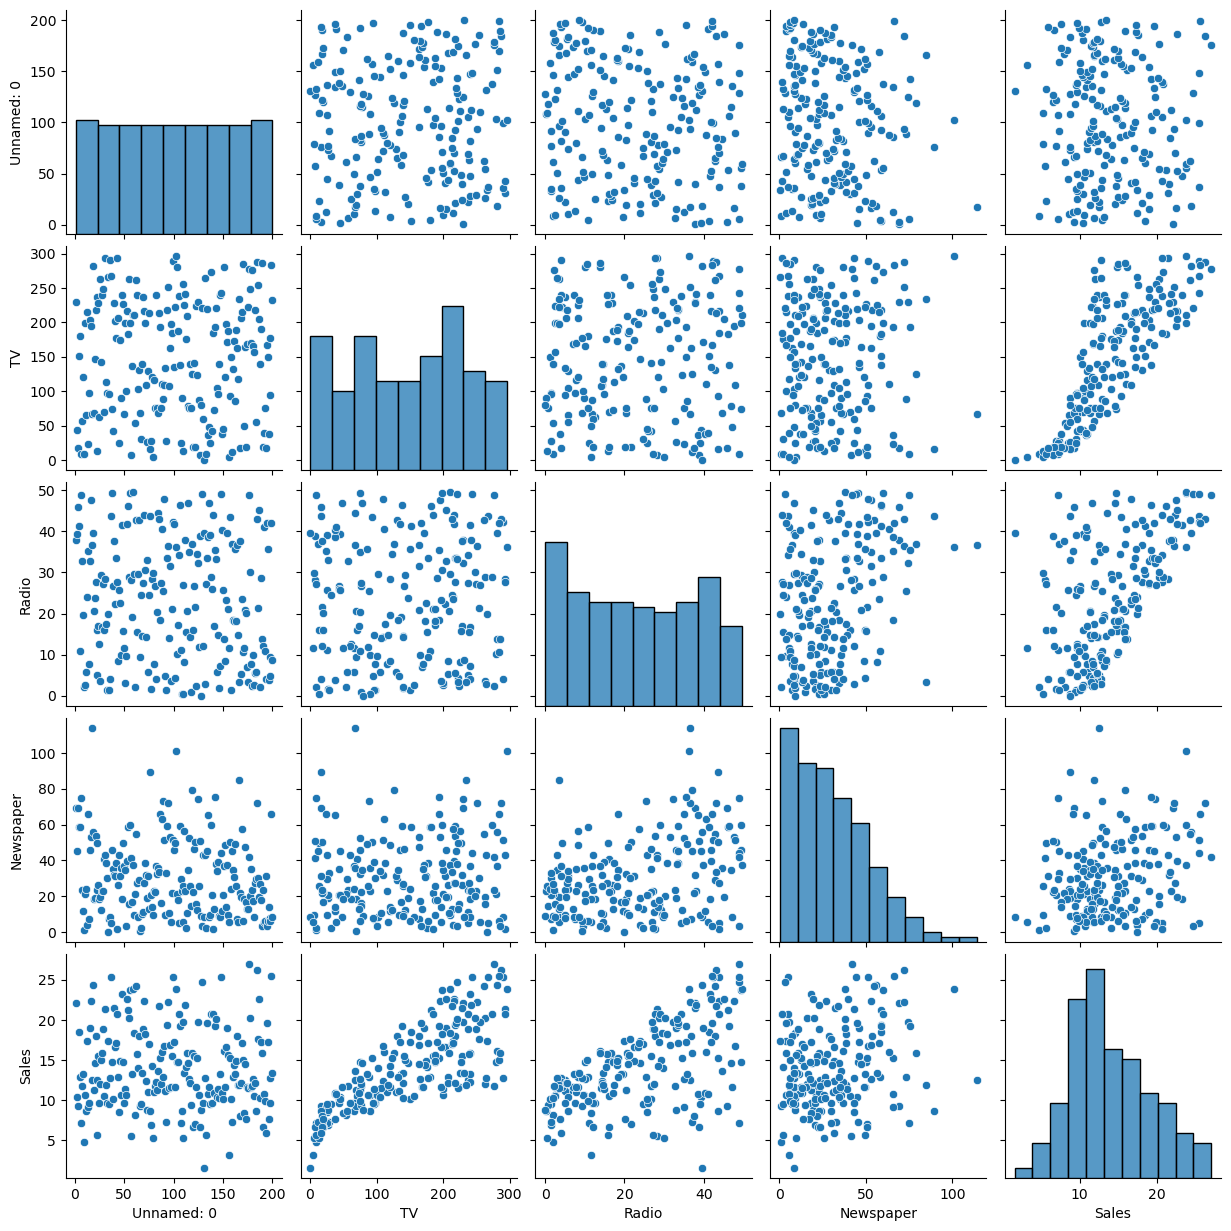

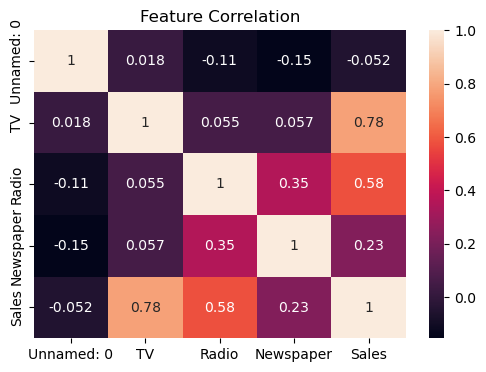

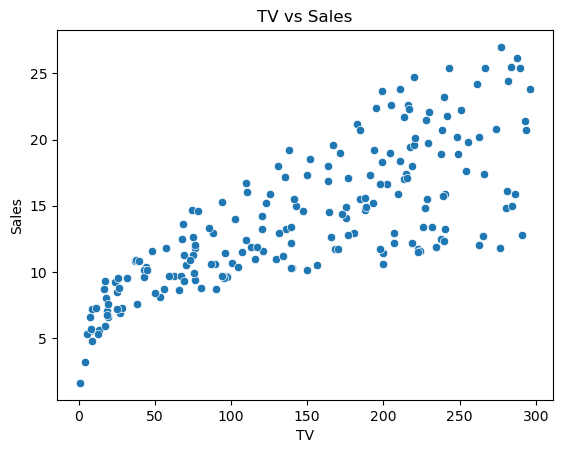

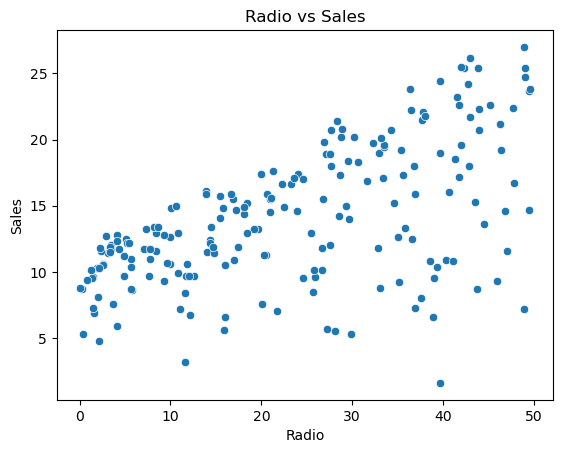

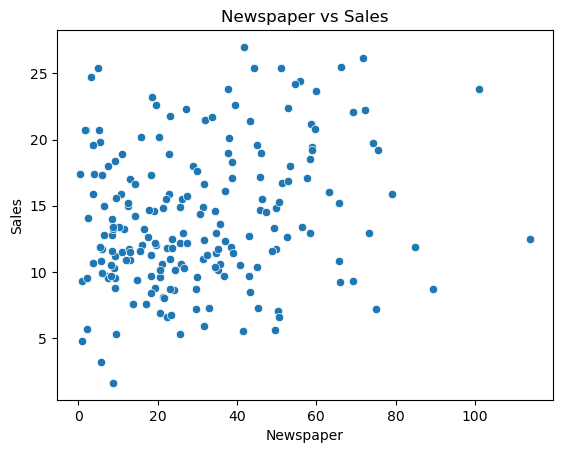

In [6]:
# Pairplot
sns.pairplot(data4)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(data4.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation")
plt.show()

# Scatter plots
plt.figure()
sns.scatterplot(x=data4['TV'], y=data4['Sales'])
plt.title("TV vs Sales")
plt.show()

plt.figure()
sns.scatterplot(x=data4['Radio'], y=data4['Sales'])
plt.title("Radio vs Sales")
plt.show()

plt.figure()
sns.scatterplot(x=data4['Newspaper'], y=data4['Sales'])
plt.title("Newspaper vs Sales")
plt.show()

## Features

In [7]:
X = data4[['TV', 'Radio', 'Newspaper']]
y = data4['Sales']

## Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Prediction

In [10]:
y_pred = model.predict(X_test)

## Evaluation

In [11]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.4607567168117606
R2 Score: 0.899438024100912


## Visualization

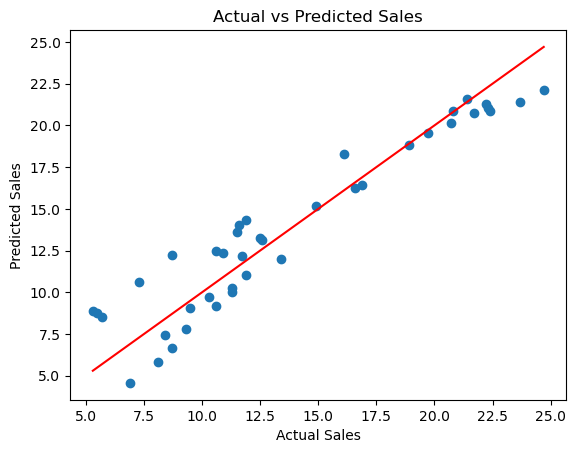

In [12]:
plt.figure()

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

### 🧠 Insights:

- TV advertising has the strongest impact on sales performance.
- Radio also shows a positive relationship with sales.
- Newspaper advertising has the weakest impact.
- The model shows a strong relationship between advertising spend and sales.
- Increasing marketing budget in TV and Radio channels can improve sales outcomes.